# ***Neurotechnology & BCI Theory***
### *Abhishek Amit Raje:BM22BTECH11002*

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.io as sio
from scipy.signal import stft, spectrogram
from scipy.signal.windows import dpss

In [ ]:
# convert .mat file to numpy array
cond1=sio.loadmat("Condition1.mat")
mat1 = cond1['final_mat_condition3']
cond2=sio.loadmat("Condition2.mat")
mat2 = cond2['final_mat_condition7']

## **Time-frequency analysis**

### **1. Construct TFRs using two methods (STFT, Multitaper, Wavelet, multiresolution TFR) of your choice from the visual evoked potential signals and plot them**.

**Short Time Fourier Transform**
$$
STFT\text{{x(t)}}(t,f)=X(t,f)=\int_{-\infty}^{∞}x(\tau)w(t-τ).e^{-j2\pi ft}dτ
$$
where

*   $X(t,f)$ is the time frequency representation of the signal
*   $x(t)$ is the time domain representation of the signal
*   $w(t)$ is the window function
*   $t$ and $f$ represent time and frequency



In [ ]:
sampling_rate=512

In [ ]:
def plot_stft(t, f, Zxx):
    plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud', cmap='jet')
    plt.colorbar()
    plt.title('STFT Magnitude')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.ylim(0, 30)
    plt.show()

In [ ]:
def compute_stft(signal, fs, window_size):
    f, t, Zxx = stft(signal, fs, nperseg=window_size)
    # print(Zxx.shape, len(f), len(t))
    plot_stft(t, f, Zxx)
    return f, t, Zxx

**Multitaper Power Spectra Esmitimate**
$$
P(f)=\frac{1}{K}\Sigma_{k=1}^KFFT\left(x[n].w_k[n]\right)^2
$$
where
* $x[n]$ is the signal
* $w_k[n]$ represents the $k_{th}$ window
* $P(f)$ is the power spectrum estimate
* These window functions are othogornal to each other
* There is a trade off between the resolution and the variance of the resut

In [ ]:
def compute_multitaper(signal, sample_rate, nw=10, k=15):
    t = np.arange(len(signal)) / sample_rate
    window_length = len(signal)
    dpss_windows = dpss(window_length, nw, k)
    spectrum = np.zeros((k, window_length // 2 + 1))
    freqs = np.fft.rfftfreq(window_length, d=1 / sample_rate)
    for i in range(k):
        tapered_signal = signal * dpss_windows[i]
        fft_result = np.fft.rfft(tapered_signal)
        spectrum[i] = np.abs(fft_result)
    avg_spectrum = np.mean(spectrum, axis=0)
    # Change: plot the average spectrum instead of individual tapers
    plt.plot(freqs, avg_spectrum, color='orange')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power')
    plt.title('Multitaper Power Spectrum')
    plt.xlim(0, 50)
    plt.show()
    return freqs, avg_spectrum

In [ ]:
def average_data(mat):
  return np.mean(mat, axis=0)

In [ ]:
def plot_signal(signal,sampling_rate):
  time = np.arange(0, len(signal)/sampling_rate, 1/sampling_rate)
  plt.plot(time, signal, 'r',alpha=0.7)
  plt.xlabel('Time (s)')
  plt.ylabel('Amplitude')
  plt.show()

In [ ]:
def plot_trial(data,fs):
  plt.figure(figsize=(10, 6))
  for i in range(data.shape[0]):
    time = np.arange(0, len(data[i])/fs, 1/fs)
    plt.plot(time,data[i],alpha=0.5)
  plt.xlabel('Time (s)')
  plt.ylabel('Amplitude')

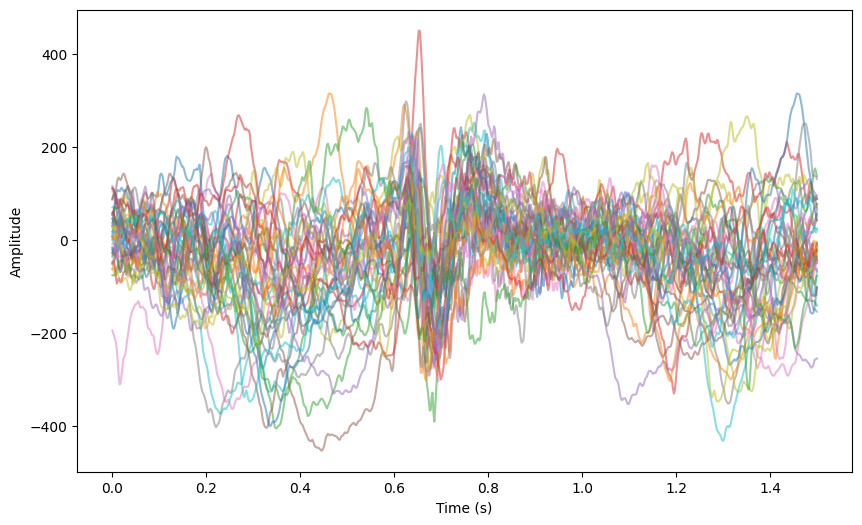

In [ ]:
plot_trial(mat1,512)

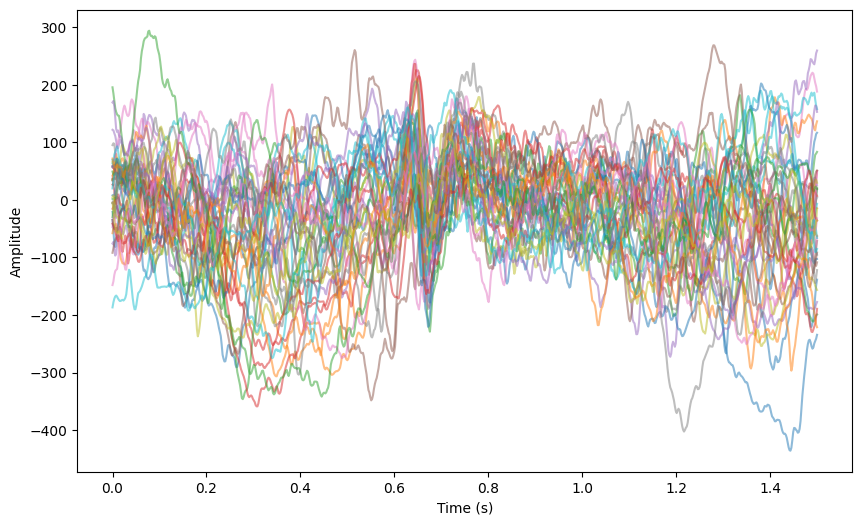

In [ ]:
plot_trial(mat2,512)

#### **Condition 1 Evoked Potential**

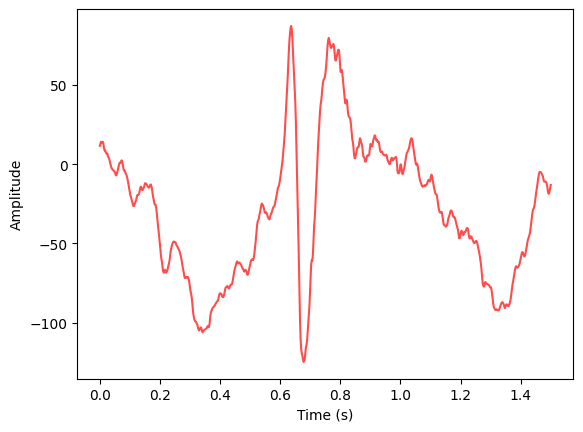

In [ ]:
plot_signal(average_data(mat1),sampling_rate)

#### **Condition 2 Evoked Potential**

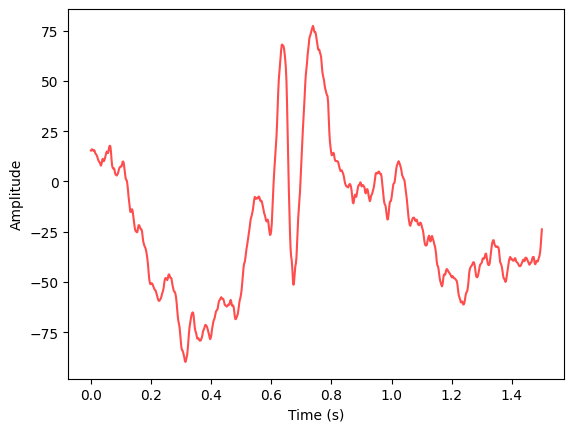

In [ ]:
plot_signal(average_data(mat2),sampling_rate)

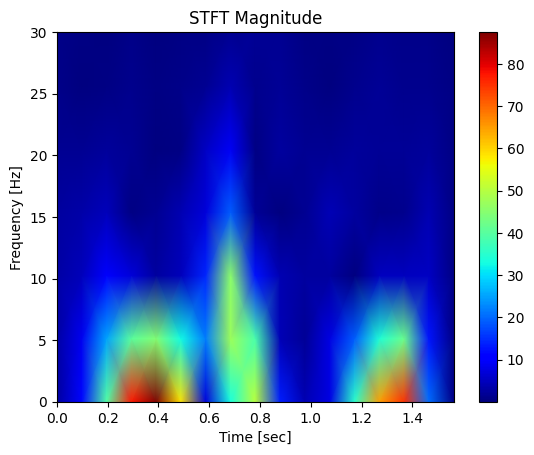

In [ ]:
t,f,Zxx=compute_stft(average_data(mat1),sampling_rate,100)

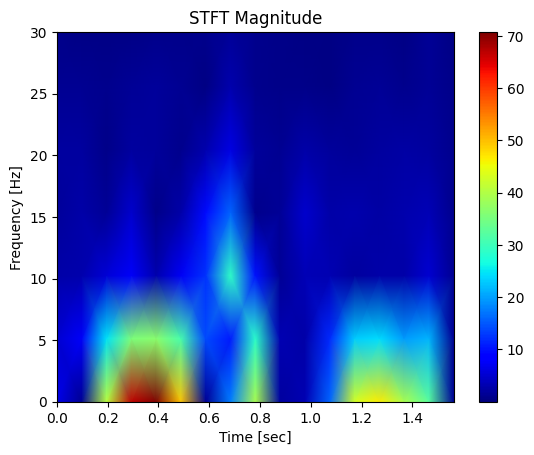

In [ ]:
t,f,Zxx=compute_stft(average_data(mat2),sampling_rate,100)

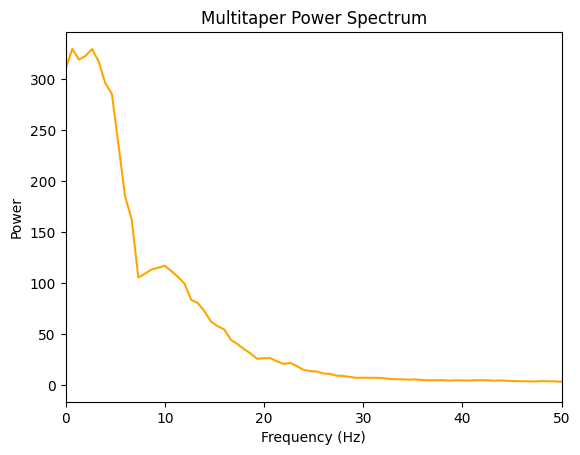

In [ ]:
freqs_mt, spectrum_mt=compute_multitaper(average_data(mat1),sampling_rate)

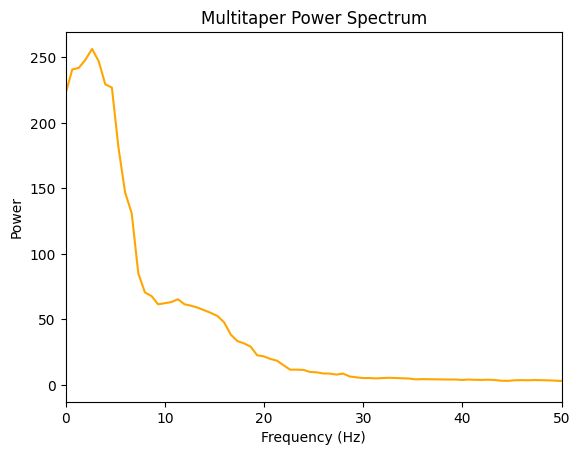

In [ ]:
freqs_mt, spectrum_mt=compute_multitaper(average_data(mat2),sampling_rate)

### **2.What are the various parameters that need to be assigned? How does the TFR vary with different parameters & why?**


#### **stft  parameters are :**

* Larger windows yield sharper frequency peaks but blur time localization.

* This is becuae on increasing the size of the window in the time domain we are shrinking it in the freq domain hence ,frequency can be easily identified while time localization is reduced.
#### **Multi taper parameters are:**

* $n_w$ represents the time-half bandwidth product, a larger nw results in smoother spectral estimates ,A smaller nw gives sharper spectral peaks

* $k$ represents the number of windows Each taper is a different window applied to the signal before computing its spectrum.More k leads to increase spectra




### **3. Are you able to visualize the 1/f structure of the noise floor in the TFR? Explain.**

*   Yes , in both the stft and multi-taper signal the $\frac{1}{f}$ floor can be observed.It is more obvious in the multi-taper though.



## **Normalization of TFR**

   ### **4.Use two modes to normalize the TFRs (absolute, relative, relative change). Do you find any differences? Explain the outcomes.**

#### **Absolute Normalization**
$X'(t,f)=\frac{X(t,f)}{argmax(X(t,f))}$

In [ ]:
def normalize_absolute_fr(tfr,mode="absolute"):
    max_power = np.max(tfr, axis=0, keepdims=True)
    return tfr / max_power

#### **Relative Normalization**
$X'(t,f)=\frac{X(t,f)}{mean(X(t,f))}$

In [ ]:
def  normalize_relative_fr(tfr,mode="relative"):
    mean_power = np.mean(tfr, axis=0, keepdims=True)
    return tfr / mean_power

#### **Relative Change Normalization**
$X'(t,f)=\frac{X(t,f)-mean(X(t,f))}{mean(X(t,f))}$

In [ ]:
def normalize_relative_chage_tfr(tfr,mode="relative_change"):
    mean_power = np.mean(tfr, axis=0, keepdims=True)
    stand_dev  = np.std(tfr, axis=0, keepdims=True)
    return (tfr - mean_power) / mean_power

In [ ]:
def plot_stft_2(t, f, Zxx1,Zxx2):
  #plot both the stft
  plt.subplot(2, 1, 1)
  plt.pcolormesh(t, f, np.abs(Zxx1), shading='gouraud', cmap='jet')
  plt.colorbar()
  plt.title('STFT Magnitude')
  plt.ylim(0, 30)
  plt.subplot(2, 1, 2)
  plt.pcolormesh(t, f, np.abs(Zxx2), shading='gouraud', cmap='jet')
  plt.colorbar()
  plt.ylabel('Frequency [Hz]')
  plt.xlabel('Time [sec]')
  plt.ylim(0, 30)
  plt.show()

In [ ]:
def compute_stft_normalize(signal_1,signal_2, fs, window_size,mode):
    f, t, Zxx1 = stft(signal_1, fs, nperseg=window_size)
    f, t, Zxx2 = stft(signal_2, fs, nperseg=window_size)
    if mode=="absolute":
      Zxx1=normalize_absolute_fr(Zxx1)
      Zxx2=normalize_absolute_fr(Zxx2)
    elif mode=="relative":
      Zxx1=normalize_relative_fr(Zxx1)
      Zxx2=normalize_relative_fr(Zxx2)

    else:
      Zxx1=normalize_relative_chage_tfr(Zxx1)
      Zxx2=normalize_relative_chage_tfr(Zxx2)
    plot_stft_2(t, f, Zxx1,Zxx2)
    return f, t, Zxx1,Zxx2
    # print(Zxx.shape, len(f), len(t))

In [ ]:
evoked_signal_1=average_data(mat1)
evoked_signal_2=average_data(mat2)

#### **Absolute Normalization**

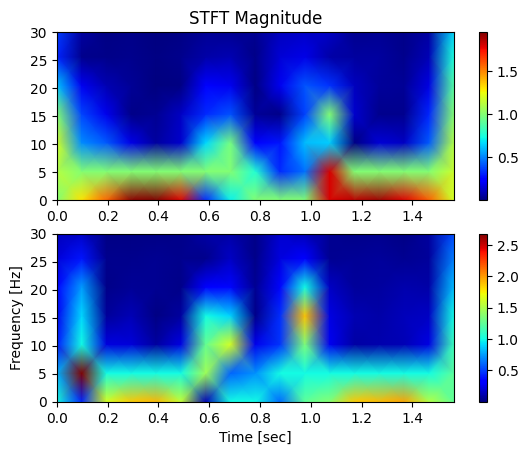

In [ ]:
t,f,Zxx1,Zxx2=compute_stft_normalize(evoked_signal_1,evoked_signal_2,sampling_rate,100,"absolute")

#### **Relative Normalization**

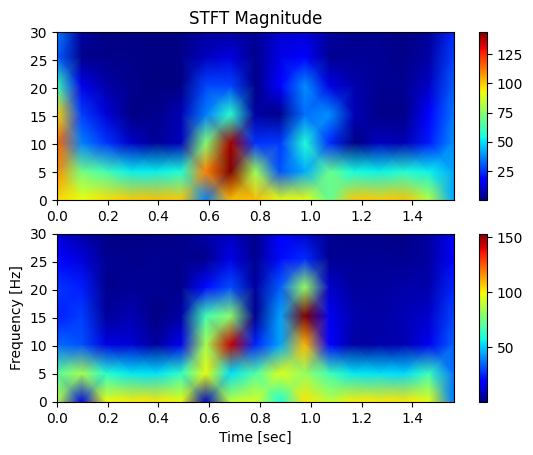

In [ ]:
t,f,Zxx1,Zxx2=compute_stft_normalize(evoked_signal_1,evoked_signal_2,sampling_rate,100,"relative")

#### **Relative Change Normalization**

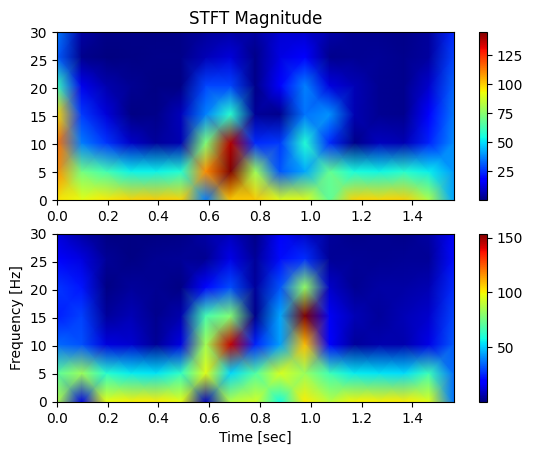

In [ ]:
t,f,Zxx1,Zxx2=compute_stft_normalize(evoked_signal_1,evoked_signal_2,sampling_rate,100,"relative_change")

#### **Interpretation**

* Absolute normalization involves normalization by the max value in of the time-frequency respone

* Relative normalization normalizes by the mean of the spectrum
* Relative normalization normalizes by the mean and the standard deviation of the signal

#### **Do you find any differences? Explain the outcomes.**
* more distinct and comparable accross time and frequency spectra is being observed as we go from absolute to relative to relative change
* Hence for further analysis I will consider relatice change

### **5.Why do you need to perform normalization? Explain with figures front the data.**
* Normalization is required to make different signal and elements comparable.As we see in the above figures without normalization the time freq spectra looked almost similar but upon normalization the distinct differences can be compared and seen

## **Functional meaning**

### **6.Are there any differences between conditions that can be visually observed from the TFR or evoked potential plots?**

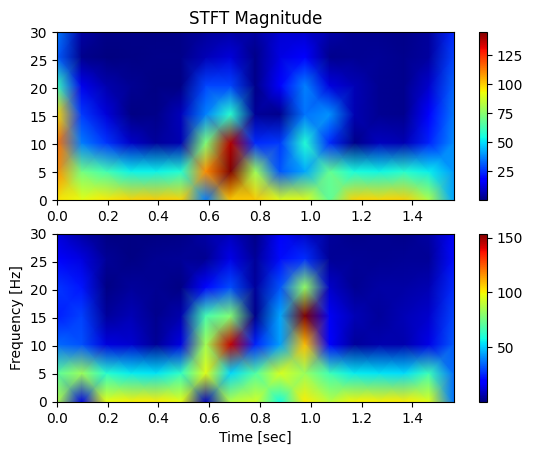

In [ ]:
t,f,Zxx1,Zxx2=compute_stft_normalize(evoked_signal_1,evoked_signal_2,sampling_rate,100,"relative_change")

#### **Differences Observed**
* In Condition 1 there is a much stronger activation of the alpha band for alpha band(5Hz-10Hz) components from 0.6s-0.8s which fades slowly.In Condition 2 strong activation observed for beta band
* In condition 2 there is a distinct decrease in the freq components from 0-5 Hz which is relatively weaker than condition 1
* In Condition 2 there is much stronger beta freq observed during 0.9-1.1s duration

### **7.Can you propose a strategy to extract summary values and statistics on them?**
* The mean median mode and standard devation of the spectra can be evaluted at multiple time intervals for both the two evoked potentials.

### **8.What functional meaning of the differences?**
* Faces have more salience associated with them than objects